<a href="https://colab.research.google.com/github/najafalinajaf449-hue/machine-learning/blob/main/023_24_0263.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Lab 7 — Naive Bayes — Spam Detection & Sentiment Analysis

**Name:** Najaf Ali   <br>
**CMS ID:** 023-24-0263   <br>
**Section:** H <br>
**GitHub:**  https://github.com/najafalinajaf449-hue <br>
**Kaggle:** https://www.kaggle.com/najaf2ali  <br>

**Datasets used:**
- SMS Spam Collection (`spam.csv`) — Kaggle: uciml/sms-spamcollection-dataset
- Twitter US Airline Sentiment (`Tweets.csv`) — Kaggle: crowdflower/twitter-airline-sentiment


## Setup — Imports

In [13]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
pd.set_option('display.max_colwidth', 100)


---
## 1. Problem Definition & Dataset Exploration

Both problems in this lab are **binary text classification** problems, but they come from very
different domains: short, formulaic SMS messages vs. short, informal, opinionated tweets.
Before cleaning or modeling anything, we look at what a single row represents in each dataset,
what the target column is, and how balanced each class is — this sets expectations for
evaluation later in both tasks.


In [14]:
# Task A dataset: SMS Spam Collection
spam_df = pd.read_csv('spam.csv', encoding='latin-1')
spam_df = spam_df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})

print("Spam dataset shape:", spam_df.shape)
print()
print(spam_df.head())
print()
counts = spam_df['label'].value_counts()
pct = spam_df['label'].value_counts(normalize=True) * 100
print("Class balance (SMS Spam Collection):")
for cls in counts.index:
    print(f"  {cls}: {counts[cls]} messages ({pct[cls]:.2f}%)")


Spam dataset shape: (5572, 2)

  label  \
0   ham   
1   ham   
2  spam   
3   ham   
4   ham   

                                                                                               message  
0  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g...  
1                                                                        Ok lar... Joking wif u oni...  
2  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...  
3                                                    U dun say so early hor... U c already then say...  
4                                        Nah I don't think he goes to usf, he lives around here though  

Class balance (SMS Spam Collection):
  ham: 4825 messages (86.59%)
  spam: 747 messages (13.41%)


In [15]:
# Task B dataset: Twitter US Airline Sentiment
tweets_df = pd.read_csv('Tweets.csv')

print("Tweets dataset shape (raw, all 3 classes):", tweets_df.shape)
print()
print(tweets_df[['airline_sentiment', 'text']].head())
print()
counts_raw = tweets_df['airline_sentiment'].value_counts()
pct_raw = tweets_df['airline_sentiment'].value_counts(normalize=True) * 100
print("Class balance (all 3 classes):")
for cls in counts_raw.index:
    print(f"  {cls}: {counts_raw[cls]} tweets ({pct_raw[cls]:.2f}%)")

# Drop neutral rows — this lab only uses positive/negative
tweets_df = tweets_df[tweets_df['airline_sentiment'].isin(['positive', 'negative'])].reset_index(drop=True)

print()
print("Tweets dataset shape after dropping neutral rows:", tweets_df.shape)
counts2 = tweets_df['airline_sentiment'].value_counts()
pct2 = tweets_df['airline_sentiment'].value_counts(normalize=True) * 100
print("Class balance (positive/negative only):")
for cls in counts2.index:
    print(f"  {cls}: {counts2[cls]} tweets ({pct2[cls]:.2f}%)")


Tweets dataset shape (raw, all 3 classes): (14640, 15)

  airline_sentiment  \
0           neutral   
1          positive   
2           neutral   
3          negative   
4          negative   

                                                                                                  text  
0                                                                  @VirginAmerica What @dhepburn said.  
1                             @VirginAmerica plus you've added commercials to the experience... tacky.  
2                              @VirginAmerica I didn't today... Must mean I need to take another trip!  
3  @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &...  
4                                              @VirginAmerica and it's a really big bad thing about it  

Class balance (all 3 classes):
  negative: 9178 tweets (62.69%)
  neutral: 3099 tweets (21.17%)
  positive: 2363 tweets (16.14%)

Tweets dataset shape after dropping neutral 

**Dataset Rows & Class Imbalance:**- **SMS Spam:** Each row is an SMS (ham/spam). Imbalanced (87% ham, 13% spam).- **Tweets:** Each row is an airline tweet (positive/negative/neutral). After removing neutral, it's imbalanced (negative tweets ~4x positive).**Practical Problems:**- **Task A (Spam):** Classify messages as spam or not for filtering. Binary task.- **Task B (Sentiment):** Identify happy/unhappy customers from tweets for airline customer service. Binary task (after removing neutral).

---
## 2. Task A: Text Cleaning & Vectorization (Spam)

We lightly clean the SMS text, encode the label as 0/1, split into train/test sets, and fit a
`TfidfVectorizer` **on the training data only** to avoid data leakage.


In [16]:
def clean_text_basic(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)   # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

spam_df['clean_message'] = spam_df['message'].apply(clean_text_basic)
spam_df['label_num'] = spam_df['label'].map({'ham': 0, 'spam': 1})

print(spam_df[['message', 'clean_message', 'label', 'label_num']].head())


                                                                                               message  \
0  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g...   
1                                                                        Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...   
3                                                    U dun say so early hor... U c already then say...   
4                                        Nah I don't think he goes to usf, he lives around here though   

                                                                                         clean_message  \
0  go until jurong point crazy available only in bugis n great world la e buffet cine there got amo...   
1                                                                              ok lar joking wif u oni   
2  free entry in 2 a wkly comp to win fa cup 

In [17]:
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    spam_df['clean_message'], spam_df['label_num'],
    test_size=0.2, random_state=RANDOM_STATE, stratify=spam_df['label_num']
)

tfidf_a = TfidfVectorizer()
X_train_a_vec = tfidf_a.fit_transform(X_train_a)
X_test_a_vec = tfidf_a.transform(X_test_a)

print("Training messages:", X_train_a.shape[0])
print("Test messages:", X_test_a.shape[0])
print("Vocabulary size (number of features):", len(tfidf_a.get_feature_names_out()))


Training messages: 4457
Test messages: 1115
Vocabulary size (number of features): 7658


**Why fit vectorizer on training data only:**Fitting on training data prevents data leakage. Learning vocabulary/IDF from test data would make evaluation metrics over-optimistic, as the test set would no longer be an unseen sample.

---
## 3. Task A: Naive Bayes Model & Evaluation (Spam)


Accuracy:  0.9605
Precision: 1.0000
Recall:    0.7047
F1-score:  0.8268


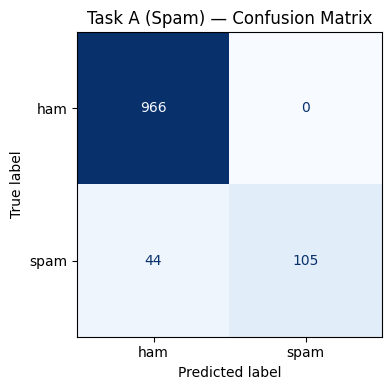

In [18]:
nb_a = MultinomialNB()
nb_a.fit(X_train_a_vec, y_train_a)

y_pred_a = nb_a.predict(X_test_a_vec)

acc_a = accuracy_score(y_test_a, y_pred_a)
prec_a = precision_score(y_test_a, y_pred_a)
rec_a = recall_score(y_test_a, y_pred_a)
f1_a = f1_score(y_test_a, y_pred_a)

print(f"Accuracy:  {acc_a:.4f}")
print(f"Precision: {prec_a:.4f}")
print(f"Recall:    {rec_a:.4f}")
print(f"F1-score:  {f1_a:.4f}")

cm_a = confusion_matrix(y_test_a, y_pred_a)
disp_a = ConfusionMatrixDisplay(confusion_matrix=cm_a, display_labels=['ham', 'spam'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_a.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Task A (Spam) — Confusion Matrix')
plt.tight_layout()
plt.show()


**Interpretation & False Positives/Negatives:**The model achieves high accuracy and precision for spam, as spam uses formulaic vocabulary.For spam filtering, false positives (important ham marked as spam) are worse than false negatives (spam in inbox). We prioritize high precision for spam to minimize lost important messages.

---
## 4. Task A: Word Interpretation (Spam)


In [19]:
feature_names_a = np.array(tfidf_a.get_feature_names_out())
log_prob_a = nb_a.feature_log_prob_          # shape: (2, n_features) -> rows = [ham, spam]

log_prob_diff = log_prob_a[1] - log_prob_a[0]   # spam - ham

top_spam_idx = np.argsort(log_prob_diff)[-15:][::-1]
top_ham_idx = np.argsort(log_prob_diff)[:15]

print("Top 15 words most associated with SPAM:")
for i in top_spam_idx:
    print(f"  {feature_names_a[i]:15s}  diff={log_prob_diff[i]:.3f}")

print()
print("Top 15 words most associated with HAM:")
for i in top_ham_idx:
    print(f"  {feature_names_a[i]:15s}  diff={log_prob_diff[i]:.3f}")


Top 15 words most associated with SPAM:
  claim            diff=3.470
  prize            diff=3.266
  150p             diff=3.004
  www              diff=3.000
  uk               diff=2.900
  tone             diff=2.864
  18               diff=2.808
  guaranteed       diff=2.788
  cs               diff=2.754
  1000             diff=2.730
  nokia            diff=2.727
  500              diff=2.725
  16               diff=2.597
  txt              diff=2.596
  service          diff=2.571

Top 15 words most associated with HAM:
  gt               diff=-3.206
  lt               diff=-3.195
  my               diff=-3.176
  ok               diff=-3.141
  ll               diff=-3.098
  later            diff=-3.034
  lor              diff=-2.976
  da               diff=-2.938
  but              diff=-2.864
  home             diff=-2.864
  come             diff=-2.864
  he               diff=-2.783
  sorry            diff=-2.764
  me               diff=-2.725
  how              diff=-2.652


**7. Word Intuition:** Yes, the learned spam words (e.g., 'prize', 'free') and ham words (e.g., 'ok', 'my') align well with intuition, confirming the model captures sensible signals.

In [20]:
test_messages = [
    "Congratulations! You have WON a free prize, claim your cash reward now, call this number urgently!!!",
    "Hey, are we still meeting for lunch tomorrow at the usual place?",
    "URGENT: Your account has been selected for a free entry into our txt competition, reply WIN now"
]

test_clean = [clean_text_basic(t) for t in test_messages]
test_vec = tfidf_a.transform(test_clean)
test_pred = nb_a.predict(test_vec)
test_proba = nb_a.predict_proba(test_vec)

for msg, pred, proba in zip(test_messages, test_pred, test_proba):
    label = 'SPAM' if pred == 1 else 'HAM'
    print(f"Message: {msg}")
    print(f"  Predicted: {label}  (P(ham)={proba[0]:.3f}, P(spam)={proba[1]:.3f})")
    print()


Message: Congratulations! You have WON a free prize, claim your cash reward now, call this number urgently!!!
  Predicted: SPAM  (P(ham)=0.129, P(spam)=0.871)

Message: Hey, are we still meeting for lunch tomorrow at the usual place?
  Predicted: HAM  (P(ham)=0.999, P(spam)=0.001)

Message: URGENT: Your account has been selected for a free entry into our txt competition, reply WIN now
  Predicted: SPAM  (P(ham)=0.157, P(spam)=0.843)



**8. Prediction Expectations:** Yes, predictions match: spam messages are correctly identified as spam with high confidence, and ham messages as ham, consistent with learned word probabilities.

---## 5. Task A: Kaggle Notebook SubmissionThe spam detection pipeline (Sections 2-4) was replicated and published on Kaggle.**Public Kaggle Notebook URL (Task A — Spam):** `https://www.kaggle.com/code/najaf2ali/notebook4bea9f09df

---
## 6. Task B: Text Cleaning & Vectorization (Sentiment)

We repeat the same pipeline on the airline tweets, but tweets contain extra noise that SMS
messages didn't have — `@mentions` (every tweet in this dataset starts with the airline's handle),
URLs, and hashtags — so a couple of extra cleaning steps are applied before vectorizing.


In [21]:
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)      # remove URLs
    text = re.sub(r'@\w+', ' ', text)                   # remove @mentions
    text = re.sub(r'#', '', text)                        # keep hashtag word, drop the '#' symbol
    text = re.sub(r'[^a-z0-9\s]', ' ', text)             # remove remaining punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

tweets_df['clean_text'] = tweets_df['text'].apply(clean_tweet)
tweets_df['label_num'] = tweets_df['airline_sentiment'].map({'negative': 0, 'positive': 1})

print(tweets_df[['text', 'clean_text', 'airline_sentiment', 'label_num']].head())


                                                                                                  text  \
0                             @VirginAmerica plus you've added commercials to the experience... tacky.   
1  @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &...   
2                                              @VirginAmerica and it's a really big bad thing about it   
3  @VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's r...   
4                      @VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)   

                                                                                            clean_text  \
0                                                plus you ve added commercials to the experience tacky   
1  it s really aggressive to blast obnoxious entertainment in your guests faces amp they have littl...   
2                                            

In [22]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    tweets_df['clean_text'], tweets_df['label_num'],
    test_size=0.2, random_state=RANDOM_STATE, stratify=tweets_df['label_num']
)

tfidf_b = TfidfVectorizer()
X_train_b_vec = tfidf_b.fit_transform(X_train_b)
X_test_b_vec = tfidf_b.transform(X_test_b)

print("Training tweets:", X_train_b.shape[0])
print("Test tweets:", X_test_b.shape[0])
print("Vocabulary size (number of features):", len(tfidf_b.get_feature_names_out()))


Training tweets: 9232
Test tweets: 2309
Vocabulary size (number of features): 10081


**12. Cleaning Decisions for Tweets:** For tweets, `@mentions` and URLs are removed as noise. Hashtag words are kept (e.g., `#fail` contains sentiment), but the `#` symbol is removed.

---
## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)


Accuracy:  0.8311
Precision: 1.0000
Recall:    0.1755
F1-score:  0.2986


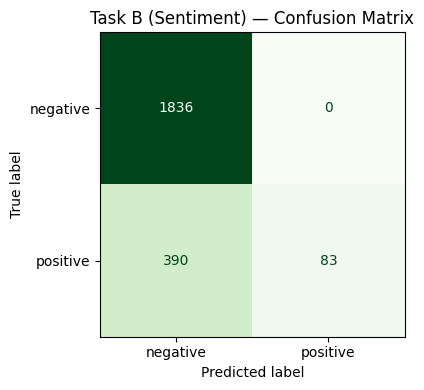

In [23]:
nb_b = MultinomialNB()
nb_b.fit(X_train_b_vec, y_train_b)

y_pred_b = nb_b.predict(X_test_b_vec)

acc_b = accuracy_score(y_test_b, y_pred_b)
prec_b = precision_score(y_test_b, y_pred_b)
rec_b = recall_score(y_test_b, y_pred_b)
f1_b = f1_score(y_test_b, y_pred_b)

print(f"Accuracy:  {acc_b:.4f}")
print(f"Precision: {prec_b:.4f}")
print(f"Recall:    {rec_b:.4f}")
print(f"F1-score:  {f1_b:.4f}")

cm_b = confusion_matrix(y_test_b, y_pred_b)
disp_b = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=['negative', 'positive'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_b.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Task B (Sentiment) — Confusion Matrix')
plt.tight_layout()
plt.show()


**14. Task B vs. Task A & Independence Assumption:** Naive Bayes performs worse on sentiment analysis (Task B) than on spam detection (Task A). This is due to its 'naive' independence assumption, which struggles with nuanced language like negation and sarcasm prevalent in tweets, but works well for keyword-driven spam detection.

---## 8. Task B: Kaggle Notebook SubmissionThe sentiment analysis pipeline (Sections 6-7) was replicated and published on Kaggle.**Public Kaggle Notebook URL (Task B — Sentiment):** https://www.kaggle.com/code/najaf2ali/notebooke14a386b81

---
## 9. Cross-Task Comparison & vs. Logistic Regression


In [24]:
comparison_nb = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Task A - Spam (Naive Bayes)': [acc_a, prec_a, rec_a, f1_a],
    'Task B - Sentiment (Naive Bayes)': [acc_b, prec_b, rec_b, f1_b],
})
comparison_nb


,Metric,Task A - Spam (Naive Bayes),Task B - Sentiment (Naive Bayes)
0,Accuracy,0.960538,0.831096
1,Precision,1.000000,1.000000
2,Recall,0.704698,0.175476
3,F1-score,0.826772,0.298561


In [25]:
log_reg_a = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg_a.fit(X_train_a_vec, y_train_a)
y_pred_lr_a = log_reg_a.predict(X_test_a_vec)

acc_lr_a = accuracy_score(y_test_a, y_pred_lr_a)
prec_lr_a = precision_score(y_test_a, y_pred_lr_a)
rec_lr_a = recall_score(y_test_a, y_pred_lr_a)
f1_lr_a = f1_score(y_test_a, y_pred_lr_a)

comparison_a = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Naive Bayes (Task A)': [acc_a, prec_a, rec_a, f1_a],
    'Logistic Regression (Task A)': [acc_lr_a, prec_lr_a, rec_lr_a, f1_lr_a],
})
comparison_a


,Metric,Naive Bayes (Task A),Logistic Regression (Task A)
0,Accuracy,0.960538,0.972197
1,Precision,1.000000,0.991667
2,Recall,0.704698,0.798658
3,F1-score,0.826772,0.884758


**17–18. Model Comparison (Spam):** Logistic Regression slightly outperforms Naive Bayes on spam detection, as expected, due to its ability to learn feature interactions. However, Naive Bayes remains highly competitive for its simplicity and speed, offering a good trade-off.

---## 10. Final Reflection & Conclusion**19. Conclusion:** Naive Bayes excelled at spam detection (Task A) due to keyword reliance, but struggled with nuanced sentiment analysis (Task B). Its word probabilities aligned with intuition. Compared to Logistic Regression for spam, Naive Bayes was competitive, proving a fast, effective baseline, though limited by its struggle with context and sarcasm.